# Important imports

In [199]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Read Data

In [200]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Univariat Analysis

In [201]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


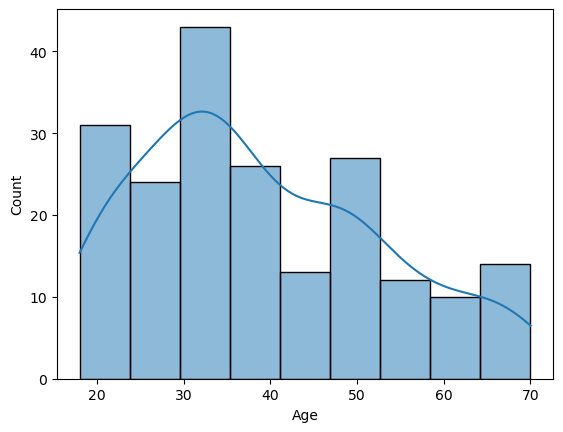

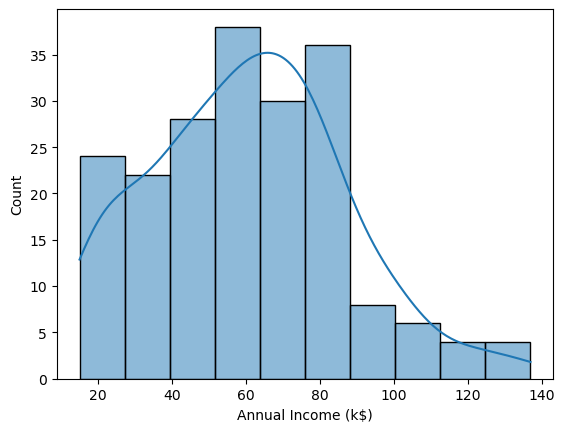

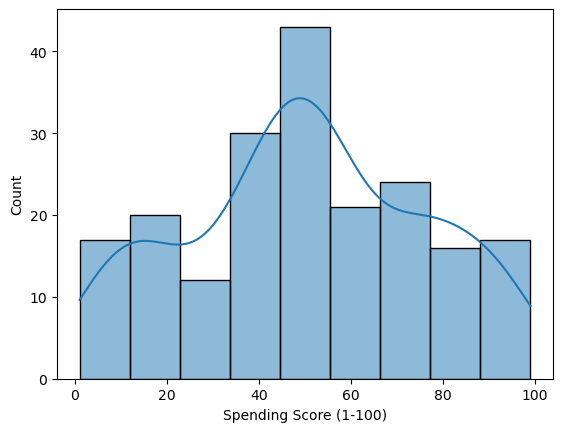

In [202]:
exclude = ["CustomerID"] 
num_cols = df.select_dtypes(include=["number"]).columns
num_cols = [x for x in num_cols if x not in exclude]
for i in num_cols:
    plt.figure()
    sns.histplot(df[i], kde=True)

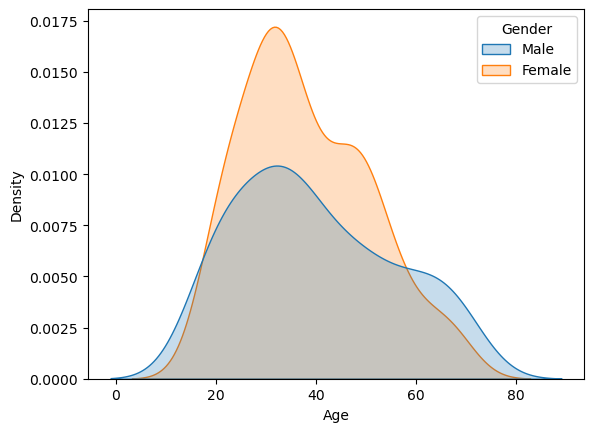

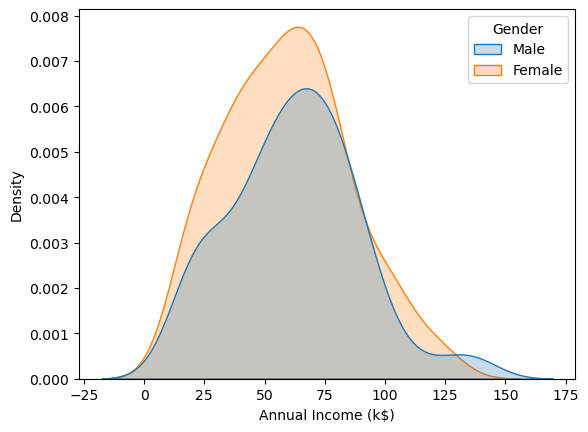

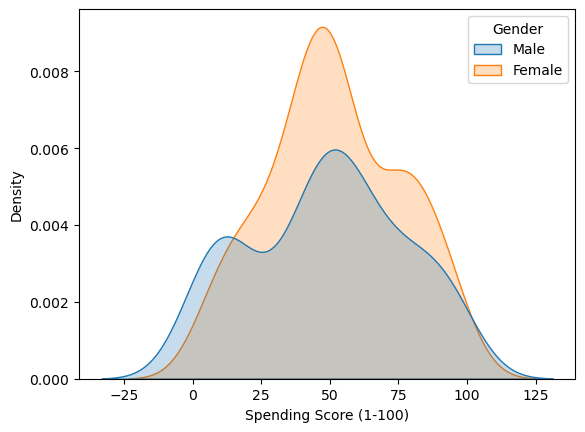

In [203]:
for i in num_cols:
    plt.figure()
    sns.kdeplot(df, x=i,fill=True, hue='Gender')


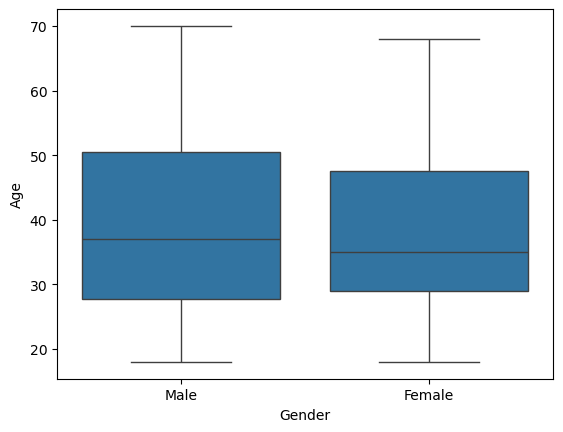

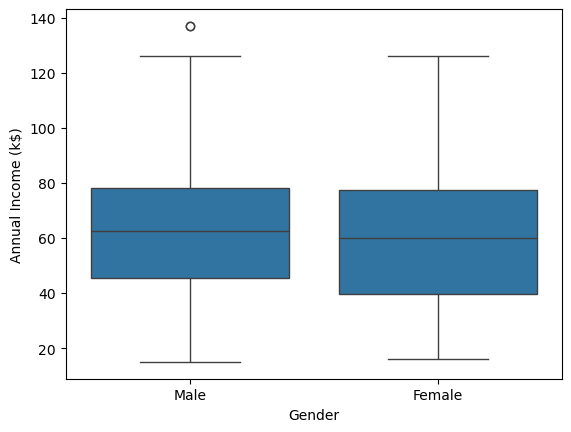

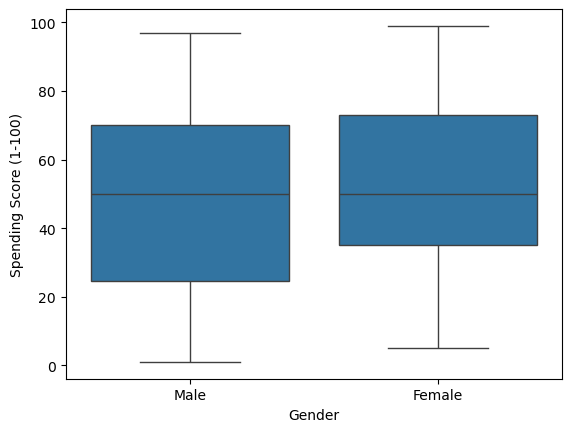

In [204]:
for i in num_cols:
    plt.figure()
    sns.boxplot(df, x='Gender', y=i)

In [205]:
df['Gender'].value_counts(normalize=True)

Gender
Female    0.56
Male      0.44
Name: proportion, dtype: float64

# Bivariat Analysis

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

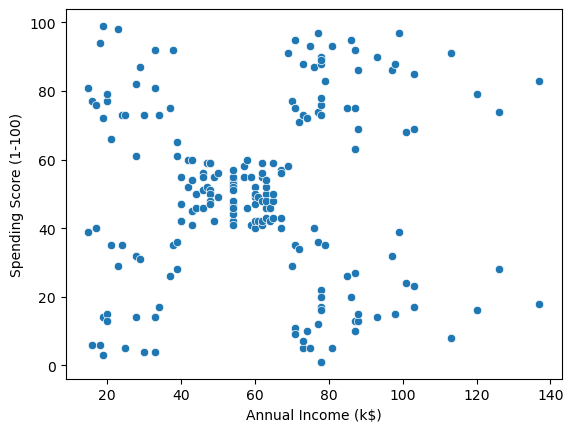

In [206]:
sns.scatterplot(df, x='Annual Income (k$)', y='Spending Score (1-100)')		

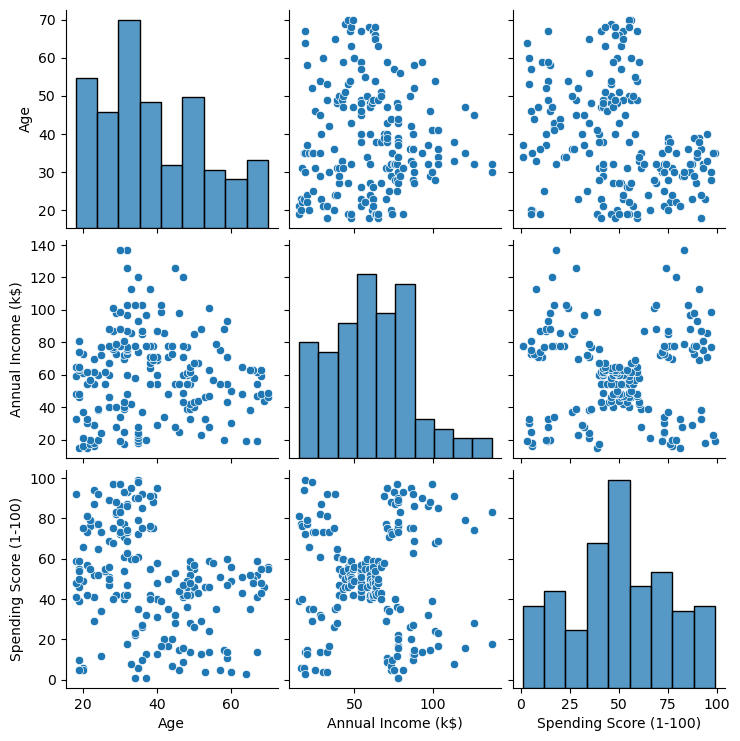

In [207]:
sns.pairplot(df[num_cols])

In [208]:
df.groupby('Gender')[num_cols].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Gender,,,
Female,38.098214,59.250000,51.526786
Male,39.806818,62.227273,48.511364


In [209]:
df[num_cols].corr()

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


<Axes: >

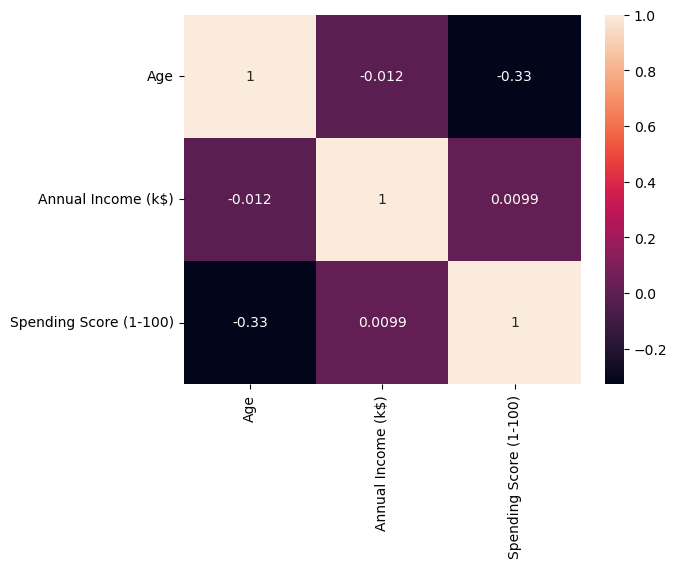

In [210]:
sns.heatmap(df[num_cols].corr(), annot=True)

# Clustering

## Univariate Clustering

In [211]:

first_cluster = KMeans(n_clusters=3)
first_cluster.fit(df[['Annual Income (k$)']])

c:\Users\EslamRadwan\Miniconda3\envs\pydata-book\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [212]:
first_cluster.labels_

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

In [213]:
df['Income Cluster'] = first_cluster.labels_  
df.head()  

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


In [214]:
df['Income Cluster'].value_counts()

Income Cluster
0    86
2    58
1    56
Name: count, dtype: int64

In [215]:
first_cluster.inertia_

25640.457784396833

In [216]:
inertia_scores = []
for i in range(1, 11):
    km = KMeans(n_clusters=i)
    km.fit(df[['Annual Income (k$)']])
    inertia_scores.append(km.inertia_)

c:\Users\EslamRadwan\Miniconda3\envs\pydata-book\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\EslamRadwan\Miniconda3\envs\pydata-book\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\EslamRadwan\Miniconda3\envs\pydata-book\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\EslamRadwan\Miniconda3\envs\pydata-book\lib\site-packag

<Axes: >

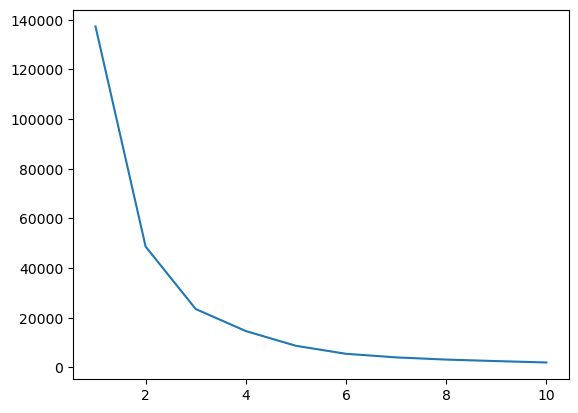

In [217]:
sns.lineplot( x=range(1, 11), y=inertia_scores)

In [218]:
df.groupby('Income Cluster')[num_cols].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Income Cluster,,,
0,41.279070,60.906977,50.337209
1,36.910714,92.142857,50.517857
2,37.120690,29.551724,49.689655


## Bivariate Cluster

In [219]:
second_cluster = KMeans(n_clusters=5)
second_cluster.fit(df[['Spending Score (1-100)', 'Annual Income (k$)']])

c:\Users\EslamRadwan\Miniconda3\envs\pydata-book\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [220]:
df['Spending and Income Cluster'] = second_cluster.labels_
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster
0,1,Male,19,15,39,2,3
1,2,Male,21,15,81,2,1
2,3,Female,20,16,6,2,3
3,4,Female,23,16,77,2,1
4,5,Female,31,17,40,2,3


In [221]:
inertia_scores = []

for i in range(1, 11):
    km = KMeans(n_clusters=i)
    km.fit(df[['Spending Score (1-100)', 'Annual Income (k$)']])
    inertia_scores.append(km.inertia_)

c:\Users\EslamRadwan\Miniconda3\envs\pydata-book\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\EslamRadwan\Miniconda3\envs\pydata-book\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\EslamRadwan\Miniconda3\envs\pydata-book\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\EslamRadwan\Miniconda3\envs\pydata-book\lib\site-packag

<Axes: >

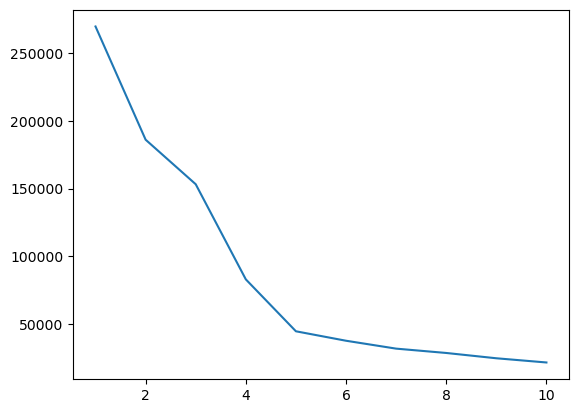

In [222]:
sns.lineplot(x=range(1, 11), y=inertia_scores)

In [223]:
centers = pd.DataFrame(second_cluster.cluster_centers_, columns=['x', 'y'])
centers

,x,y
0,17.114286,88.200000
1,79.363636,25.727273
2,82.128205,86.538462
3,20.913043,26.304348
4,49.518519,55.296296


In [224]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Income Cluster',
       'Spending and Income Cluster'],
      dtype='object')

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

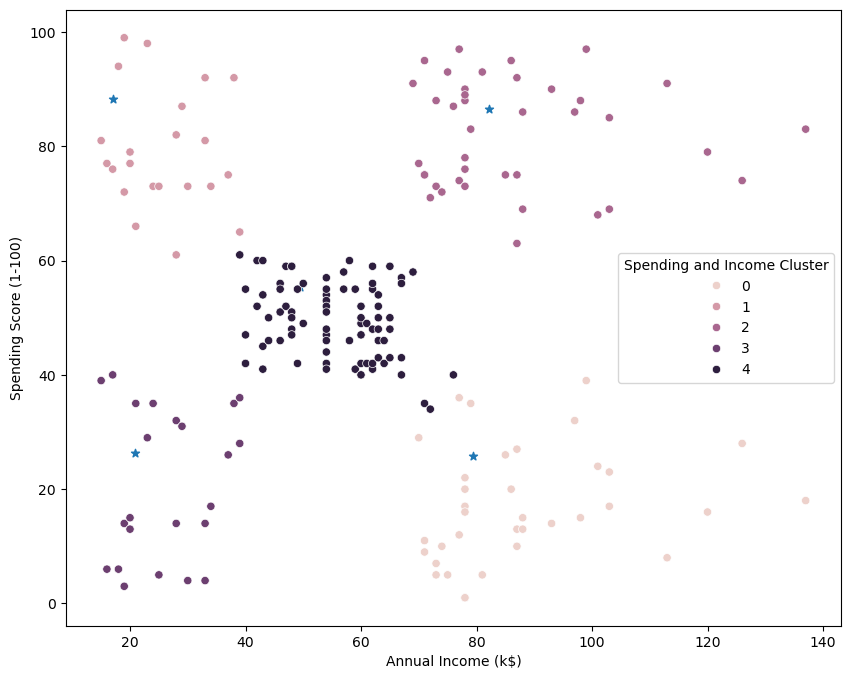

In [225]:
plt.figure(figsize=(10, 8))
plt.scatter(x=centers['x'], y=centers['y'], marker='*')
sns.scatterplot(df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Spending and Income Cluster')

In [226]:
pd.crosstab(df['Spending and Income Cluster'], df['Gender'])

Gender,Female,Male
Spending and Income Cluster,,
0,16,19
1,13,9
2,21,18
3,14,9
4,48,33


In [227]:
df.groupby('Spending and Income Cluster')[num_cols].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Spending and Income Cluster,,,
0,41.114286,88.200000,17.114286
1,25.272727,25.727273,79.363636
2,32.692308,86.538462,82.128205
3,45.217391,26.304348,20.913043
4,42.716049,55.296296,49.518519


## Multivariate Clustering

In [228]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df = pd.get_dummies(df, drop_first=True)

df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster,Gender_Male
0,1,19,15,39,2,3,True
1,2,21,15,81,2,1,True
2,3,20,16,6,2,3,False
3,4,23,16,77,2,1,False
4,5,31,17,40,2,3,False


In [ ]:
df[num_cols] = scaler.fit_transform(df[num_cols])
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster,Gender_Male
0,1,-1.424569,-1.738999,-0.434801,2,3,True
1,2,-1.281035,-1.738999,1.195704,2,1,True
2,3,-1.352802,-1.700830,-1.715913,2,3,False
3,4,-1.137502,-1.700830,1.040418,2,1,False
4,5,-0.563369,-1.662660,-0.395980,2,3,False


In [234]:
df[num_cols].head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [235]:
inertia_scores = []
for i in range(1, 11):
    km = KMeans(n_clusters=i)
    km.fit(df[num_cols])
    inertia_scores.append(km.inertia_)
    

c:\Users\EslamRadwan\Miniconda3\envs\pydata-book\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\EslamRadwan\Miniconda3\envs\pydata-book\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\EslamRadwan\Miniconda3\envs\pydata-book\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\EslamRadwan\Miniconda3\envs\pydata-book\lib\site-packag

<Axes: >

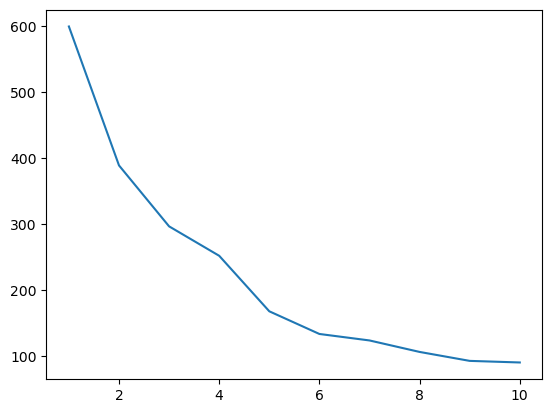

In [237]:
sns.lineplot(x=range(1, 11), y=inertia_scores)